### 05 - Transfer Learning with ResNet18

This notebook implements a transfer learning model for traffic sign image classification using a pretrained ResNet18 architecture.

The experiment follows a two-stage training strategy:

1. **Feature extraction** – the pretrained convolutional layers are frozen and only the new classification layer is trained.
2. **Fine-tuning** – the final residual block is unfrozen and trained using a smaller learning rate.

The main objectives are to:

- investigate whether ImageNet-pretrained features improve traffic sign classification;
- compare transfer learning with the custom CNN baseline;
- analyse overall and per-class classification performance;
- record model efficiency measures for later model comparison.

In [43]:
import os
import json
import random
import time
import copy
from pathlib import Path
import platform

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms, models
from torchvision.models import ResNet18_Weights

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("PyTorch version:", torch.__version__)

PyTorch version: 2.2.2


In [44]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"Random seed set to {SEED}.")

Random seed set to 42.


In [45]:
print("Computer architecture:", platform.machine())
print("macOS version:", platform.mac_ver()[0])
print("PyTorch version:", torch.__version__)

print("CUDA available:", torch.cuda.is_available())
print("MPS built:", torch.backends.mps.is_built())
print("MPS available:", torch.backends.mps.is_available())

Computer architecture: x86_64
macOS version: 10.16
PyTorch version: 2.2.2
CUDA available: False
MPS built: True
MPS available: False


Because the experiment is run locally on an Intel-based Mac without CUDA or MPS support, training is performed on the CPU.

In [46]:
device = torch.device("cpu")

available_threads = os.cpu_count() or 1
cpu_threads = max(1, available_threads - 1)

torch.set_num_threads(cpu_threads)

print("Device:", device)
print("Available CPU threads:", available_threads)
print("PyTorch CPU threads:", torch.get_num_threads())

Device: cpu
Available CPU threads: 8
PyTorch CPU threads: 7


##### 1. Experimental Configuration

The main experimental settings are defined in one place to make the notebook easier to reproduce and modify. The file paths and main training settings are defined below.

The notebook is stored inside the `notebooks` directory. Therefore, the project root is one directory above the current working directory.

In [47]:
PROJECT_ROOT = Path("..")

DATA_DIR = PROJECT_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw" / "archive"
PROCESSED_DATA_DIR = DATA_DIR / "processed"

TRAIN_CSV = PROCESSED_DATA_DIR / "train_split.csv"
VAL_CSV = PROCESSED_DATA_DIR / "validation_split.csv"
TEST_CSV = PROCESSED_DATA_DIR / "test_split.csv"

MODEL_DIR = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = RESULTS_DIR / "figures"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Current working directory:", Path.cwd())
print("Project root:", PROJECT_ROOT.resolve())
print("Raw data directory:", RAW_DATA_DIR.resolve())
print("Training CSV:", TRAIN_CSV.resolve())
print("Validation CSV:", VAL_CSV.resolve())
print("Test CSV:", TEST_CSV.resolve())

Current working directory: /Users/liuyuhan/Desktop/traffic_recognition/notebooks
Project root: /Users/liuyuhan/Desktop/traffic_recognition
Raw data directory: /Users/liuyuhan/Desktop/traffic_recognition/data/raw/archive
Training CSV: /Users/liuyuhan/Desktop/traffic_recognition/data/processed/train_split.csv
Validation CSV: /Users/liuyuhan/Desktop/traffic_recognition/data/processed/validation_split.csv
Test CSV: /Users/liuyuhan/Desktop/traffic_recognition/data/processed/test_split.csv


In [48]:
required_paths = {
    "Raw data directory": RAW_DATA_DIR,
    "Training split CSV": TRAIN_CSV,
    "Validation split CSV": VAL_CSV,
    "Test split CSV": TEST_CSV
}

for name, path in required_paths.items():
    if not path.exists():
        raise FileNotFoundError(
            f"{name} was not found:\n{path.resolve()}"
        )

print("All required data paths were found successfully.")

All required data paths were found successfully.


In [49]:
IMAGE_SIZE = 224
BATCH_SIZE = 16
NUM_WORKERS = 0

# Stage 1: train only the new classifier
STAGE1_EPOCHS = 5
STAGE1_LR = 1e-3

# Stage 2: fine-tune layer4 and the classifier
STAGE2_EPOCHS = 5
STAGE2_BACKBONE_LR = 1e-5
STAGE2_CLASSIFIER_LR = 1e-4

# Early stopping
PATIENCE = 2

# Regularisation
WEIGHT_DECAY = 1e-4
DROPOUT_RATE = 0.30

# Saved output files
STAGE1_MODEL_PATH = MODEL_DIR / "resnet18_stage1_best.pth"
FINAL_MODEL_PATH = MODEL_DIR / "resnet18_best.pth"

HISTORY_PATH = RESULTS_DIR / "resnet18_training_history.csv"
METRICS_PATH = RESULTS_DIR / "resnet18_metrics.json"
PER_CLASS_PATH = RESULTS_DIR / "resnet18_per_class_results.csv"

print("Configuration created successfully.")

Configuration created successfully.


##### 2. Load the Dataset Splits

The training, validation and test splits created during preprocessing are loaded from CSV files.

The column names are inspected before constructing the custom PyTorch dataset.

In [50]:
train_dataframe = pd.read_csv(TRAIN_CSV)
val_dataframe = pd.read_csv(VAL_CSV)
test_dataframe = pd.read_csv(TEST_CSV)

print("Training set shape:", train_dataframe.shape)
print("Validation set shape:", val_dataframe.shape)
print("Test set shape:", test_dataframe.shape)

print("\nTraining CSV columns:")
print(train_dataframe.columns.tolist())

display(train_dataframe.head())

Training set shape: (31367, 8)
Validation set shape: (7842, 8)
Test set shape: (12630, 8)

Training CSV columns:
['Width', 'Height', 'Roi.X1', 'Roi.Y1', 'Roi.X2', 'Roi.Y2', 'ClassId', 'Path']


,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,56,56,5,5,51,51,12,Train/12/00012_00031_00018.png
1,27,28,6,5,22,23,5,Train/5/00005_00031_00001.png
2,92,94,8,9,84,86,12,Train/12/00012_00069_00028.png
3,60,53,6,5,54,48,13,Train/13/00013_00052_00022.png
4,64,58,6,5,59,53,18,Train/18/00018_00017_00024.png


##### 3. Detecy Image Path and Label Columns

The code automatically searches for commonly used image-path and label column names.

For the GTSRB dataset, these columns are normally named `Path` and `ClassId`.

In [51]:
def find_column(dataframe, candidates, column_type):

    lower_to_original = {
        column.lower(): column
        for column in dataframe.columns
    }
    
    for candidate in candidates:
        if candidate.lower() in lower_to_original:
            return lower_to_original[candidate.lower()]
    
    raise ValueError(
        f"Could not identify the {column_type} column.\n"
        f"Available columns: {dataframe.columns.tolist()}\n"
        f"Expected one of: {candidates}"
    )

PATH_COLUMN = find_column(
    train_dataframe,
    candidates=[
        "Path",
        "path",
        "image_path",
        "filepath",
        "file_path",
        "filename"
    ],
    column_type="image path"
)

LABEL_COLUMN = find_column(
    train_dataframe,
    candidates=[
        "ClassId",
        "class_id",
        "label",
        "Label",
        "target",
        "class"
    ],
    column_type="label"
)

print("Detected path column:", PATH_COLUMN)
print("Detected label column:", LABEL_COLUMN)

Detected path column: Path
Detected label column: ClassId


In [52]:
# Confirm that all three CSV files contain the required columns
for split_name, dataframe in {
    "Training": train_dataframe,
    "Validation": val_dataframe,
    "Test": test_dataframe
}.items():
    
    if PATH_COLUMN not in dataframe.columns:
        raise ValueError(
            f"{split_name} CSV does not contain "
            f"the path column '{PATH_COLUMN}'."
        )
    
    if LABEL_COLUMN not in dataframe.columns:
        raise ValueError(
            f"{split_name} CSV does not contain "
            f"the label column '{LABEL_COLUMN}'."
        )

print("All dataset splits contain the required columns.")

All dataset splits contain the required columns.


##### 4. Class Mapping

The original class identifiers are converted into consecutive class indices.

This ensures that the labels used by the neural network range from `0` to `number_of_classes - 1`.

In [53]:
# Collect all class IDs across the three splits
all_original_labels = sorted(
    set(train_dataframe[LABEL_COLUMN].astype(int))
    | set(val_dataframe[LABEL_COLUMN].astype(int))
    | set(test_dataframe[LABEL_COLUMN].astype(int))
)

label_to_index = {
    original_label: index
    for index, original_label in enumerate(all_original_labels)
}

index_to_label = {
    index: original_label
    for original_label, index in label_to_index.items()
}

# Display names used in plots and tables
class_names = [
    f"Class {index_to_label[index]}"
    for index in range(len(index_to_label))
]

num_classes = len(class_names)

print("Number of classes:", num_classes)
print("First five class mappings:")

for original_label in all_original_labels[:5]:
    print(
        f"Original label {original_label} "
        f"-> model index {label_to_index[original_label]}"
    )

Number of classes: 43
First five class mappings:
Original label 0 -> model index 0
Original label 1 -> model index 1
Original label 2 -> model index 2
Original label 3 -> model index 3
Original label 4 -> model index 4


##### 5. Image Path Resolution

The image paths stored in the CSV files are resolved relative to the raw dataset directory.

A sample of image paths is checked before constructing the dataset.

Resolve an image path stored in the CSV:
- absolute paths;
- paths relative to `data/raw/archive`;
- paths beginning with `archive/`;
- paths beginning with `data/raw/archive/`.

In [54]:
def resolve_image_path(path_value):
    path_value = str(path_value).strip()
    path = Path(path_value)
    
    # Case 1: already an absolute valid path
    if path.is_absolute() and path.exists():
        return path
    
    # Remove leading ./ if present
    cleaned_path = Path(path_value.lstrip("./"))
    
    possible_paths = [
        RAW_DATA_DIR / cleaned_path,
        PROJECT_ROOT / cleaned_path,
        DATA_DIR / cleaned_path,
        PROCESSED_DATA_DIR / cleaned_path
    ]
    
    # Handle CSV paths that already include "archive/"
    if cleaned_path.parts and cleaned_path.parts[0].lower() == "archive":
        possible_paths.append(
            RAW_DATA_DIR.parent / cleaned_path
        )
    
    for possible_path in possible_paths:
        if possible_path.exists():
            return possible_path
    
    # Return the most likely path for a useful error message
    return RAW_DATA_DIR / cleaned_path

In [55]:
# Check a sample of stored image paths
sample_paths = train_dataframe[PATH_COLUMN].head(5)

for stored_path in sample_paths:
    resolved_path = resolve_image_path(stored_path)
    
    print("CSV path:     ", stored_path)
    print("Resolved path:", resolved_path.resolve())
    print("Exists:       ", resolved_path.exists())
    print("-" * 60)

CSV path:      Train/12/00012_00031_00018.png
Resolved path: /Users/liuyuhan/Desktop/traffic_recognition/data/raw/archive/Train/12/00012_00031_00018.png
Exists:        True
------------------------------------------------------------
CSV path:      Train/5/00005_00031_00001.png
Resolved path: /Users/liuyuhan/Desktop/traffic_recognition/data/raw/archive/Train/5/00005_00031_00001.png
Exists:        True
------------------------------------------------------------
CSV path:      Train/12/00012_00069_00028.png
Resolved path: /Users/liuyuhan/Desktop/traffic_recognition/data/raw/archive/Train/12/00012_00069_00028.png
Exists:        True
------------------------------------------------------------
CSV path:      Train/13/00013_00052_00022.png
Resolved path: /Users/liuyuhan/Desktop/traffic_recognition/data/raw/archive/Train/13/00013_00052_00022.png
Exists:        True
------------------------------------------------------------
CSV path:      Train/18/00018_00017_00024.png
Resolved path: /User

In [56]:
# Check whether image files referenced by a CSV exist
def check_missing_images(dataframe, split_name, maximum_to_show=10):
    missing_paths = []
    
    for stored_path in dataframe[PATH_COLUMN]:
        resolved_path = resolve_image_path(stored_path)
        
        if not resolved_path.exists():
            missing_paths.append(str(resolved_path))
            
            if len(missing_paths) >= maximum_to_show:
                break
    
    if missing_paths:
        print(
            f"{split_name}: at least "
            f"{len(missing_paths)} missing image paths were found."
        )
        
        for path in missing_paths:
            print("-", path)
        
        raise FileNotFoundError(
            f"Missing images were found in the {split_name} split."
        )
    
    print(f"{split_name}: all checked image paths exist.")


check_missing_images(train_dataframe, "Training")
check_missing_images(val_dataframe, "Validation")
check_missing_images(test_dataframe, "Test")

Training: all checked image paths exist.
Validation: all checked image paths exist.
Test: all checked image paths exist.


##### 6. Image Transformations

The pretrained ResNet18 model was originally trained using ImageNet images. Therefore, all images are resized to `224 × 224` pixels and normalised using the ImageNet mean and standard deviation.

Moderate augmentation is applied only to the training set:

- small rotations;
- small translations;
- small scale changes;
- moderate brightness, contrast and saturation changes.

Horizontal flipping is not used because it could change the meaning of directional traffic signs.

In [57]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    
    transforms.RandomRotation(degrees=10),
    
    transforms.RandomAffine(
        degrees=0,
        translate=(0.08, 0.08),
        scale=(0.90, 1.10)
    ),
    
    transforms.ColorJitter(
        brightness=0.20,
        contrast=0.20,
        saturation=0.15
    ),
    
    transforms.ToTensor(),
    
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])

evaluation_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    
    transforms.ToTensor(),
    
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])

print("Training and evaluation transformations created.")

Training and evaluation transformations created.


##### 7. Custom Traffic Sign Dataset

A custom PyTorch Dataset is used because the data splits are stored in CSV files rather than separate class folders.

For each sample, the dataset:

1. reads the image path from the CSV;
2. loads the image in RGB format;
3. applies the selected transformation;
4. converts the original class label into a consecutive model index.

In [58]:
# Traffic sign dataset loaded from a CSV split file
class TrafficSignDataset(Dataset):
    
    def __init__(
        self,
        dataframe,
        path_column,
        label_column,
        label_to_index,
        transform=None
    ):
        self.dataframe = dataframe.reset_index(drop=True).copy()
        self.path_column = path_column
        self.label_column = label_column
        self.label_to_index = label_to_index
        self.transform = transform
    
    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, index):
        row = self.dataframe.iloc[index]
        
        image_path = resolve_image_path(
            row[self.path_column]
        )
        
        if not image_path.exists():
            raise FileNotFoundError(
                f"Image was not found: {image_path}"
            )
        
        # Convert all images to three-channel RGB
        with Image.open(image_path) as image:
            image = image.convert("RGB")
        
        original_label = int(row[self.label_column])
        model_label = self.label_to_index[original_label]
        
        if self.transform is not None:
            image = self.transform(image)
        
        return image, model_label

In [59]:
train_dataset = TrafficSignDataset(
    dataframe=train_dataframe,
    path_column=PATH_COLUMN,
    label_column=LABEL_COLUMN,
    label_to_index=label_to_index,
    transform=train_transform
)

val_dataset = TrafficSignDataset(
    dataframe=val_dataframe,
    path_column=PATH_COLUMN,
    label_column=LABEL_COLUMN,
    label_to_index=label_to_index,
    transform=evaluation_transform
)

test_dataset = TrafficSignDataset(
    dataframe=test_dataframe,
    path_column=PATH_COLUMN,
    label_column=LABEL_COLUMN,
    label_to_index=label_to_index,
    transform=evaluation_transform
)

print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Test images:", len(test_dataset))
print("Number of classes:", num_classes)

Training images: 31367
Validation images: 7842
Test images: 12630
Number of classes: 43


##### 8. DataLoaders

The datasets are divided into mini-batches using DataLoaders.

The training set is shuffled at the start of each epoch. The validation and test sets are not shuffled.

`num_workers=0` is used because it is generally more stable for local Jupyter notebooks on macOS.

In [60]:
# Seeded generator for reproducible training-set shuffling
data_generator = torch.Generator()
data_generator.manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=False,
    generator=data_generator
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=False
)

dataloaders = {
    "train": train_loader,
    "val": val_loader
}

dataset_sizes = {
    "train": len(train_dataset),
    "val": len(val_dataset)
}

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Training batches: 1961
Validation batches: 491
Test batches: 790


In [61]:
# Inspect one batch before training
sample_images, sample_labels = next(iter(train_loader))

print("Image batch shape:", sample_images.shape)
print("Label batch shape:", sample_labels.shape)
print("Image tensor dtype:", sample_images.dtype)
print("First labels:", sample_labels[:10].tolist())

Image batch shape: torch.Size([16, 3, 224, 224])
Label batch shape: torch.Size([16])
Image tensor dtype: torch.float32
First labels: [15, 4, 1, 5, 5, 24, 9, 8, 21, 7]


##### 9. Visualise Sample Training Images

A sample of transformed training images is displayed to verify that the images and labels are loaded correctly.

ImageNet normalisation is reversed only for visualisation.

In [62]:
# Reverse ImageNet normalisation for visualisation
def denormalise_image(image_tensor):
    
    mean = torch.tensor(
        IMAGENET_MEAN,
        dtype=image_tensor.dtype
    ).view(3, 1, 1)
    
    std = torch.tensor(
        IMAGENET_STD,
        dtype=image_tensor.dtype
    ).view(3, 1, 1)
    
    image = image_tensor.cpu() * std + mean
    
    return torch.clamp(image, 0, 1)

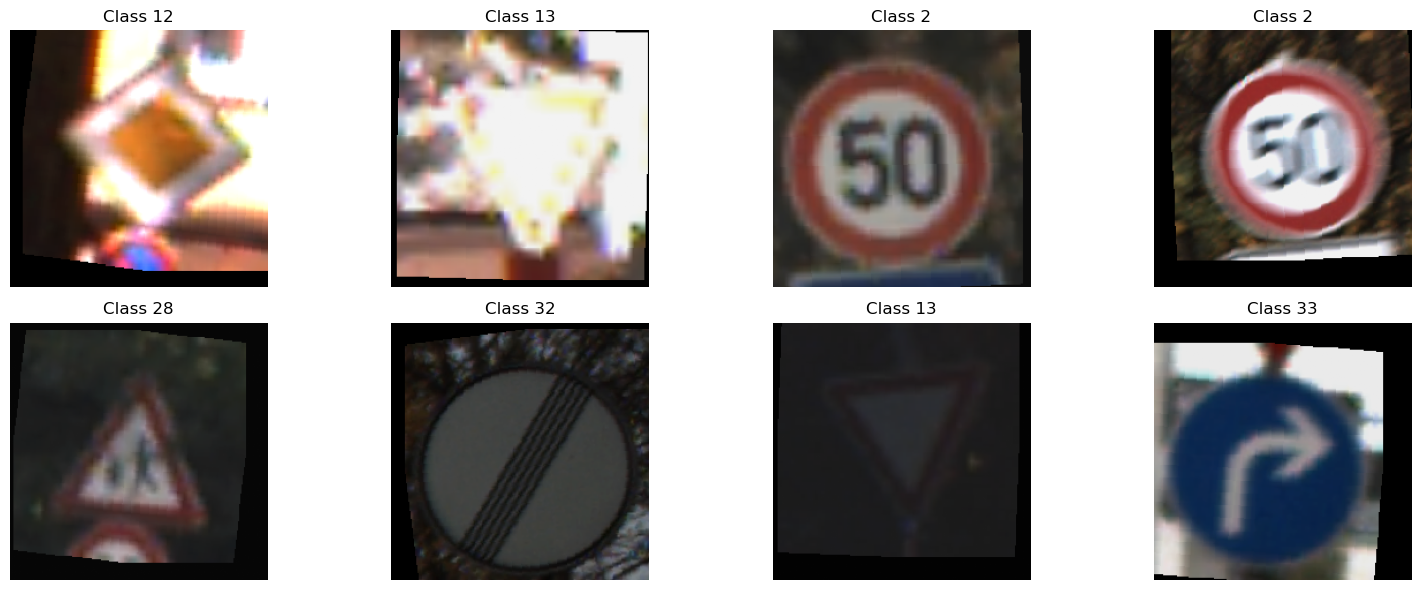

In [63]:
images, labels = next(iter(train_loader))

number_to_show = min(8, len(images))

plt.figure(figsize=(16, 6))

for index in range(number_to_show):
    plt.subplot(2, 4, index + 1)
    
    image = denormalise_image(images[index])
    image = image.permute(1, 2, 0).numpy()
    
    plt.imshow(image)
    plt.title(class_names[labels[index].item()])
    plt.axis("off")

plt.tight_layout()
plt.show()

##### 10. Class Distribution

The training-set class distribution is inspected because large differences in class frequency may influence both overall accuracy and per-class performance.

In [64]:
training_original_labels = (
    train_dataframe[LABEL_COLUMN]
    .astype(int)
    .map(label_to_index)
)

training_class_counts = (
    training_original_labels
    .value_counts()
    .sort_index()
    .reindex(range(num_classes), fill_value=0)
)

class_distribution_dataframe = pd.DataFrame({
    "class_index": range(num_classes),
    "class_name": class_names,
    "sample_count": training_class_counts.values
})

display(class_distribution_dataframe.head())

,class_index,class_name,sample_count
0,0,Class 0,168
1,1,Class 1,1776
2,2,Class 2,1800
3,3,Class 3,1128
4,4,Class 4,1584


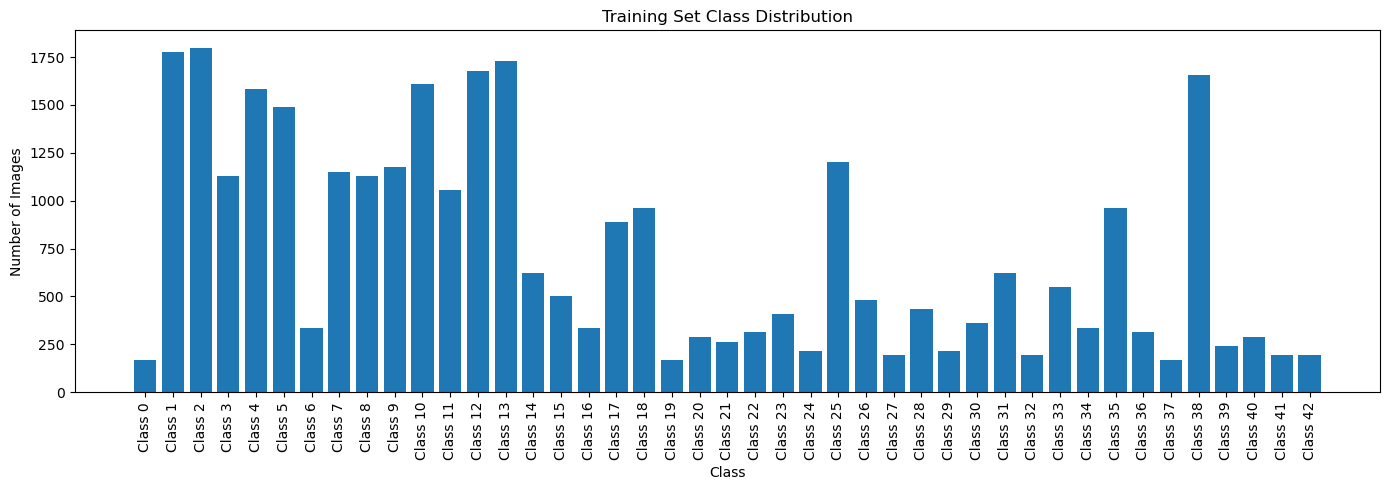

In [65]:
plt.figure(figsize=(14, 5))

plt.bar(
    class_distribution_dataframe["class_name"],
    class_distribution_dataframe["sample_count"]
)

plt.title("Training Set Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

##### 11. Pretrained ResNet18 Model

ResNet18 is loaded with pretrained ImageNet weights.

The original classification layer predicts 1,000 ImageNet classes. It is replaced with a new classification head whose output size matches the number of traffic sign classes.

During the first training stage, the pretrained backbone is frozen and only the new classification head is trainable.

In [66]:
# Load pretrained ImageNet weights
weights = ResNet18_Weights.DEFAULT

model = models.resnet18(weights=weights)

# Freeze the complete pretrained network
for parameter in model.parameters():
    parameter.requires_grad = False

# Replace the original ImageNet classifier
number_of_features = model.fc.in_features

model.fc = nn.Sequential(
    nn.Dropout(p=DROPOUT_RATE),
    nn.Linear(number_of_features, num_classes)
)

model = model.to(device)

print("New classification head:")
print(model.fc)

New classification head:
Sequential(
  (0): Dropout(p=0.3, inplace=False)
  (1): Linear(in_features=512, out_features=43, bias=True)
)


In [67]:
# Count total and currently trainable model parameters
def count_parameters(model):
    
    total_parameters = sum(
        parameter.numel()
        for parameter in model.parameters()
    )
    
    trainable_parameters = sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )
    
    return total_parameters, trainable_parameters


total_parameters, trainable_parameters = count_parameters(model)

print(f"Total parameters: {total_parameters:,}")
print(f"Trainable parameters: {trainable_parameters:,}")
print("Trainable proportion: "f"{100 * trainable_parameters / total_parameters:.2f}%")

Total parameters: 11,198,571
Trainable parameters: 22,059
Trainable proportion: 0.20%


In [68]:
print("Trainable parameters in Stage 1:")

for name, parameter in model.named_parameters():
    if parameter.requires_grad:
        print(name, tuple(parameter.shape))

Trainable parameters in Stage 1:
fc.1.weight (43, 512)
fc.1.bias (43,)


##### 12. Loss Function

Cross-entropy loss is used because this is a single-label multi-class classification problem.

In [69]:
criterion = nn.CrossEntropyLoss()

print("Loss function:", criterion)

Loss function: CrossEntropyLoss()


##### 13. Training and Validation Function

The following function trains and validates the model.

For each epoch, it records:

- training loss;
- training accuracy;
- validation loss;
- validation accuracy;
- learning rate;
- epoch duration.

The model with the lowest validation loss is saved. Early stopping is used when the validation loss does not improve for a specified number of epochs.

In [70]:
def train_model(
    model,
    dataloaders,
    dataset_sizes,
    criterion,
    optimizer,
    scheduler,
    num_epochs,
    patience,
    save_path,
    stage_name
):
    
    stage_start_time = time.time()
    
    best_model_weights = copy.deepcopy(
        model.state_dict()
    )
    
    best_validation_loss = float("inf")
    best_validation_accuracy = 0.0
    best_epoch = 0
    
    epochs_without_improvement = 0
    
    history = {
        "stage": [],
        "epoch": [],
        "train_loss": [],
        "train_accuracy": [],
        "val_loss": [],
        "val_accuracy": [],
        "learning_rate": [],
        "epoch_seconds": []
    }
    
    for epoch in range(1, num_epochs + 1):
        epoch_start_time = time.time()
        
        print()
        print(f"{stage_name} – Epoch {epoch}/{num_epochs}")
        print("-" * 55)
        
        epoch_results = {}
        
        for phase in ["train", "val"]:
            
            if phase == "train":
                model.train()
            else:
                model.eval()
            
            running_loss = 0.0
            running_correct = 0
            
            for batch_index, (inputs, labels) in enumerate(
                dataloaders[phase],
                start=1
            ):
                inputs = inputs.to(device)
                labels = labels.to(device)
                
                optimizer.zero_grad()
                
                with torch.set_grad_enabled(
                    phase == "train"
                ):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    
                    predictions = torch.argmax(
                        outputs,
                        dim=1
                    )
                    
                    if phase == "train":
                        loss.backward()
                        optimizer.step()
                
                batch_size = inputs.size(0)
                
                running_loss += (
                    loss.item() * batch_size
                )
                
                running_correct += (
                    predictions == labels
                ).sum().item()
                
                # Display occasional progress on slow CPU training
                if (
                    phase == "train"
                    and (
                        batch_index == 1
                        or batch_index % 100 == 0
                        or batch_index == len(
                            dataloaders[phase]
                        )
                    )
                ):
                    print(
                        f"Training batch "
                        f"{batch_index}/"
                        f"{len(dataloaders[phase])}"
                    )
            
            epoch_loss = (
                running_loss / dataset_sizes[phase]
            )
            
            epoch_accuracy = (
                running_correct / dataset_sizes[phase]
            )
            
            epoch_results[f"{phase}_loss"] = (
                epoch_loss
            )
            
            epoch_results[f"{phase}_accuracy"] = (
                epoch_accuracy
            )
            
            print(
                f"{phase.capitalize()} Loss: "
                f"{epoch_loss:.4f} | "
                f"{phase.capitalize()} Accuracy: "
                f"{epoch_accuracy:.4f}"
            )
        
        # Record the classifier-group learning rate
        current_learning_rate = (
            optimizer.param_groups[-1]["lr"]
        )
        
        if scheduler is not None:
            scheduler.step(
                epoch_results["val_loss"]
            )
        
        epoch_seconds = (
            time.time() - epoch_start_time
        )
        
        history["stage"].append(stage_name)
        history["epoch"].append(epoch)
        
        history["train_loss"].append(
            epoch_results["train_loss"]
        )
        
        history["train_accuracy"].append(
            epoch_results["train_accuracy"]
        )
        
        history["val_loss"].append(
            epoch_results["val_loss"]
        )
        
        history["val_accuracy"].append(
            epoch_results["val_accuracy"]
        )
        
        history["learning_rate"].append(
            current_learning_rate
        )
        
        history["epoch_seconds"].append(
            epoch_seconds
        )
        
        # Save the best model according to validation loss
        if (
            epoch_results["val_loss"]
            < best_validation_loss
        ):
            best_validation_loss = (
                epoch_results["val_loss"]
            )
            
            best_validation_accuracy = (
                epoch_results["val_accuracy"]
            )
            
            best_epoch = epoch
            
            best_model_weights = copy.deepcopy(
                model.state_dict()
            )
            
            torch.save(
                {
                    "model_state_dict": (
                        best_model_weights
                    ),
                    "best_epoch": best_epoch,
                    "best_val_loss": (
                        best_validation_loss
                    ),
                    "best_val_accuracy": (
                        best_validation_accuracy
                    ),
                    "class_names": class_names,
                    "label_to_index": (
                        label_to_index
                    ),
                    "index_to_label": (
                        index_to_label
                    ),
                    "num_classes": num_classes,
                    "image_size": IMAGE_SIZE,
                    "stage": stage_name
                },
                save_path
            )
            
            epochs_without_improvement = 0
            
            print(
                "Validation loss improved. "
                f"Model saved to {save_path}."
            )
        
        else:
            epochs_without_improvement += 1
            
            print(
                "Validation loss did not improve. "
                f"Early stopping counter: "
                f"{epochs_without_improvement}/"
                f"{patience}"
            )
        
        print(
            f"Epoch duration: "
            f"{epoch_seconds / 60:.2f} minutes"
        )
        
        if epochs_without_improvement >= patience:
            print()
            print("Early stopping activated.")
            break
    
    total_stage_seconds = (
        time.time() - stage_start_time
    )
    
    # Restore the best model from this stage
    model.load_state_dict(best_model_weights)
    
    print()
    print(f"{stage_name} completed.")
    print("Best epoch:", best_epoch)
    
    print(
        "Best validation loss:",
        f"{best_validation_loss:.4f}"
    )
    
    print(
        "Validation accuracy at best-loss epoch:",
        f"{best_validation_accuracy:.4f}"
    )
    
    print(
        "Total stage time:",
        f"{total_stage_seconds / 60:.2f} minutes"
    )
    
    stage_summary = {
        "best_epoch": best_epoch,
        "best_val_loss": best_validation_loss,
        "best_val_accuracy": (
            best_validation_accuracy
        ),
        "training_seconds": total_stage_seconds
    }
    
    return model, history, stage_summary

##### 14. Stage 1 – Feature Extraction

During the first stage, the pretrained convolutional backbone remains frozen.

Only the newly added classification head is trained. This allows the classifier to adapt the pretrained ImageNet features to the traffic sign classes without initially modifying the pretrained convolutional filters.

In [71]:
stage1_optimizer = optim.Adam(
    filter(
        lambda parameter: parameter.requires_grad,
        model.parameters()
    ),
    lr=STAGE1_LR,
    weight_decay=WEIGHT_DECAY
)

stage1_scheduler = (
    lr_scheduler.ReduceLROnPlateau(
        stage1_optimizer,
        mode="min",
        factor=0.1,
        patience=1
    )
)

print(stage1_optimizer)

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0.0001
)


In [72]:
model, stage1_history, stage1_summary = train_model(
    model=model,
    dataloaders=dataloaders,
    dataset_sizes=dataset_sizes,
    criterion=criterion,
    optimizer=stage1_optimizer,
    scheduler=stage1_scheduler,
    num_epochs=STAGE1_EPOCHS,
    patience=PATIENCE,
    save_path=STAGE1_MODEL_PATH,
    stage_name="Stage 1: Feature Extraction"
)


Stage 1: Feature Extraction – Epoch 1/5
-------------------------------------------------------
Training batch 1/1961
Training batch 100/1961
Training batch 200/1961
Training batch 300/1961
Training batch 400/1961
Training batch 500/1961
Training batch 600/1961
Training batch 700/1961
Training batch 800/1961
Training batch 900/1961
Training batch 1000/1961
Training batch 1100/1961
Training batch 1200/1961
Training batch 1300/1961
Training batch 1400/1961
Training batch 1500/1961
Training batch 1600/1961
Training batch 1700/1961
Training batch 1800/1961
Training batch 1900/1961
Training batch 1961/1961
Train Loss: 1.7939 | Train Accuracy: 0.4811
Val Loss: 1.1031 | Val Accuracy: 0.6709
Validation loss improved. Model saved to ../models/resnet18_stage1_best.pth.
Epoch duration: 21.57 minutes

Stage 1: Feature Extraction – Epoch 2/5
-------------------------------------------------------
Training batch 1/1961
Training batch 100/1961
Training batch 200/1961
Training batch 300/1961
Training

##### Results

The training and validation curves are plotted to examine convergence and possible overfitting during feature extraction.

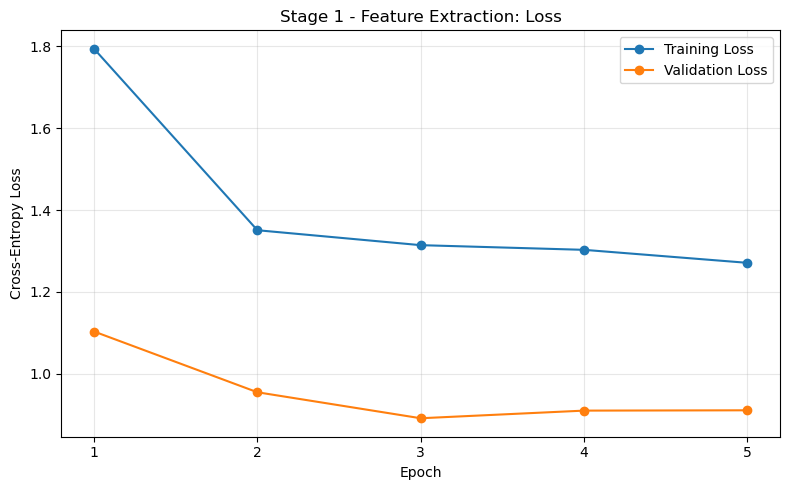

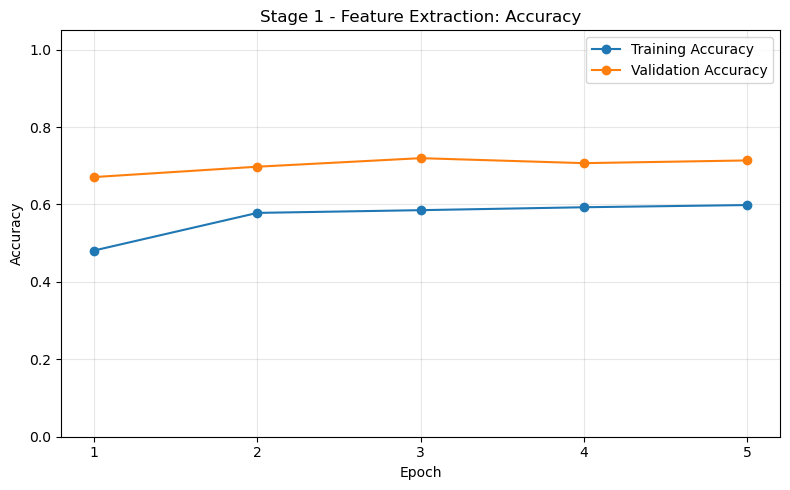

In [73]:
# Plot loss and accuracy for one training stage
def plot_stage_history(history, stage_title):
    epochs = list(
        range(1, len(history["epoch"]) + 1)
    )
    
    plt.figure(figsize=(8, 5))
    
    plt.plot(
        epochs,
        history["train_loss"],
        marker="o",
        label="Training Loss"
    )
    
    plt.plot(
        epochs,
        history["val_loss"],
        marker="o",
        label="Validation Loss"
    )
    
    plt.title(f"{stage_title}: Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Cross-Entropy Loss")
    plt.xticks(epochs)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    plt.figure(figsize=(8, 5))
    
    plt.plot(
        epochs,
        history["train_accuracy"],
        marker="o",
        label="Training Accuracy"
    )
    
    plt.plot(
        epochs,
        history["val_accuracy"],
        marker="o",
        label="Validation Accuracy"
    )
    
    plt.title(f"{stage_title}: Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.xticks(epochs)
    plt.ylim(0, 1.05)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_stage_history(stage1_history, "Stage 1 - Feature Extraction")

##### Observations

During feature extraction, the training accuracy increased from **48.11%** in the first epoch to **59.86%** in th e fifth epoch, while the highest validation accuracy was approximately **71.97%** in epoch 3.

The validation loss decreased from **1.1031** to **0.8912** during the first three epochs, before increasing slightly to **0.9099** and **0.9106** in epochs 4 and 5. This indicates that the frozen pretrained features were useful for the classification task, but training only the new classification head had reached a performance limit.

The increase in training accuracy after epoch 3 was not accompanied by further improvement in validation loss. Early stopping was therefore activated after two consecutive epochs without improvement, and the epoch 3 checkpoint was retained as the best Stage 1 model.

##### 15. Stage 2 – Fine-Tuning

During the second stage, the final residual block (`layer4`) and the classification head are trained.

Earlier layers remain frozen because they generally capture lower-level visual features such as edges, colours and textures. The final residual block contains more task-specific representations and is therefore allowed to adapt to the traffic sign dataset.

A smaller learning rate is used for the pretrained residual block to reduce the risk of overwriting useful pretrained features.

In [74]:
# Freeze all parameters again
for parameter in model.parameters():
    parameter.requires_grad = False

# Unfreeze the final residual block
for parameter in model.layer4.parameters():
    parameter.requires_grad = True

# Keep the classifier trainable
for parameter in model.fc.parameters():
    parameter.requires_grad = True

total_parameters, trainable_parameters = count_parameters(model)

print(f"Total parameters: {total_parameters:,}")
print(f"Trainable parameters: {trainable_parameters:,}")

print("Trainable proportion: "f"{100 * trainable_parameters / total_parameters:.2f}%")

Total parameters: 11,198,571
Trainable parameters: 8,415,787
Trainable proportion: 75.15%


In [75]:
trainable_components = set()

for name, parameter in model.named_parameters():
    if parameter.requires_grad:
        trainable_components.add(
            name.split(".")[0]
        )

print("Trainable components in Stage 2:", sorted(trainable_components))

Trainable components in Stage 2: ['fc', 'layer4']


In [76]:
stage2_optimizer = optim.Adam(
    [
        {
            "params": model.layer4.parameters(),
            "lr": STAGE2_BACKBONE_LR
        },
        {
            "params": model.fc.parameters(),
            "lr": STAGE2_CLASSIFIER_LR
        }
    ],
    weight_decay=WEIGHT_DECAY
)

stage2_scheduler = (
    lr_scheduler.ReduceLROnPlateau(
        stage2_optimizer,
        mode="min",
        factor=0.1,
        patience=1
    )
)

print("Stage 2 learning rates:")

for group_index, parameter_group in enumerate(
    stage2_optimizer.param_groups
):
    print(f"Parameter group {group_index}: "f"{parameter_group['lr']}")

Stage 2 learning rates:
Parameter group 0: 1e-05
Parameter group 1: 0.0001


In [77]:
model, stage2_history, stage2_summary = train_model(
    model=model,
    dataloaders=dataloaders,
    dataset_sizes=dataset_sizes,
    criterion=criterion,
    optimizer=stage2_optimizer,
    scheduler=stage2_scheduler,
    num_epochs=STAGE2_EPOCHS,
    patience=PATIENCE,
    save_path=FINAL_MODEL_PATH,
    stage_name="Stage 2: Fine-Tuning"
)


Stage 2: Fine-Tuning – Epoch 1/5
-------------------------------------------------------
Training batch 1/1961
Training batch 100/1961
Training batch 200/1961
Training batch 300/1961
Training batch 400/1961
Training batch 500/1961
Training batch 600/1961
Training batch 700/1961
Training batch 800/1961
Training batch 900/1961
Training batch 1000/1961
Training batch 1100/1961
Training batch 1200/1961
Training batch 1300/1961
Training batch 1400/1961
Training batch 1500/1961
Training batch 1600/1961
Training batch 1700/1961
Training batch 1800/1961
Training batch 1900/1961
Training batch 1961/1961
Train Loss: 0.6658 | Train Accuracy: 0.7787
Val Loss: 0.2403 | Val Accuracy: 0.9265
Validation loss improved. Model saved to ../models/resnet18_best.pth.
Epoch duration: 95.64 minutes

Stage 2: Fine-Tuning – Epoch 2/5
-------------------------------------------------------
Training batch 1/1961
Training batch 100/1961
Training batch 200/1961
Training batch 300/1961
Training batch 400/1961
Train

##### Results

The fine-tuning curves are examined to determine whether adapting the final residual block improves validation performance.

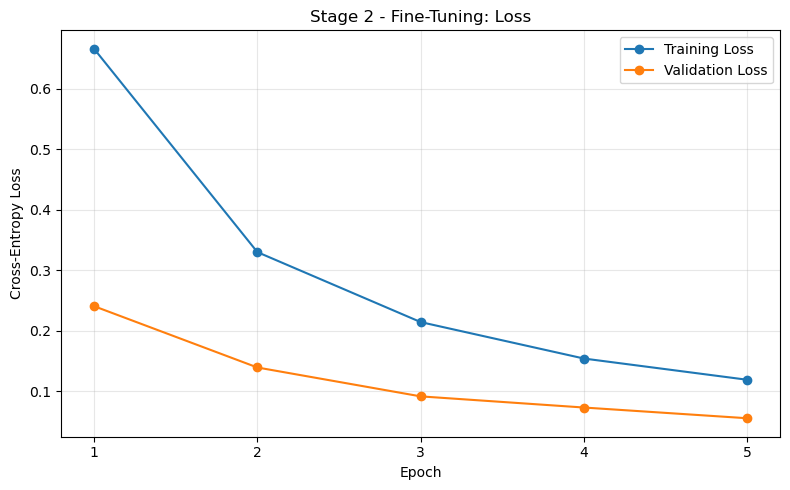

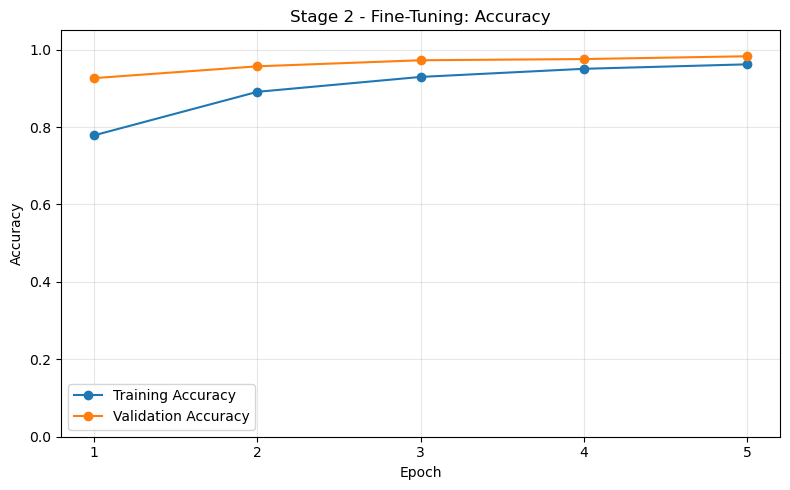

In [78]:
plot_stage_history(stage2_history, "Stage 2 - Fine-Tuning")

##### Observations

After unfreezing the final residual block, the best validation accuracy increased substantially from **71.97%** during feature extraction to **98.30%** after fine-tuning.

Training accuracy increased from **77.87%** to **96.22%**, while validation accuracy increased consistently from **92.65%** to **98.30%**. Both training and validation loss decreased throughout all five fine-tuning epochs.

There was no clear divergence between the training and validation curves. Validation accuracy remained slightly higher than training accuracy, which is likely explained by the use of data augmentation and dropout during training but not during validation.

These results show that fine-tuning the higher-level pretrained features substantially improved the model's ability to adapt to traffic sign-specific shapes, colours and symbols.

##### 16. Training History

The feature extraction and fine-tuning histories are combined to show the complete training process.

The vertical dashed line indicates the transition from frozen feature extraction to partial fine-tuning.

In [79]:
# Combine two training history dictionaries
def combine_histories(first_history, second_history):
    combined = {}
    
    for key in first_history:
        combined[key] = (
            first_history[key]
            + second_history[key]
        )
    
    combined["global_epoch"] = list(
        range(1, len(combined["epoch"]) + 1)
    )
    
    return combined


combined_history = combine_histories(
    stage1_history,
    stage2_history
)

history_dataframe = pd.DataFrame(
    combined_history
)

display(history_dataframe)

,stage,epoch,train_loss,train_accuracy,val_loss,val_accuracy,learning_rate,epoch_seconds,global_epoch
0,Stage 1: Feature Extraction,1,1.793912,0.481111,1.103121,0.670875,0.0010,1294.223953,1
1,Stage 1: Feature Extraction,2,1.350642,0.578315,0.954717,0.697654,0.0010,1170.468355,2
2,Stage 1: Feature Extraction,3,1.314128,0.585360,0.891210,0.719714,0.0010,1291.997586,3
3,Stage 1: Feature Extraction,4,1.302716,0.592916,0.909864,0.706835,0.0010,1428.567678,4
4,Stage 1: Feature Extraction,5,1.270979,0.598591,0.910638,0.713849,0.0010,6973.639329,5
5,Stage 2: Fine-Tuning,1,0.665811,0.778685,0.240349,0.926549,0.0001,5738.139700,6
6,Stage 2: Fine-Tuning,2,0.329714,0.891128,0.138995,0.957026,0.0001,1451.620010,7
7,Stage 2: Fine-Tuning,3,0.214026,0.929639,0.091244,0.972711,0.0001,3179.814135,8
8,Stage 2: Fine-Tuning,4,0.153758,0.950617,0.072802,0.975771,0.0001,1878.481094,9
9,Stage 2: Fine-Tuning,5,0.118682,0.962158,0.055082,0.983040,0.0001,1919.970979,10


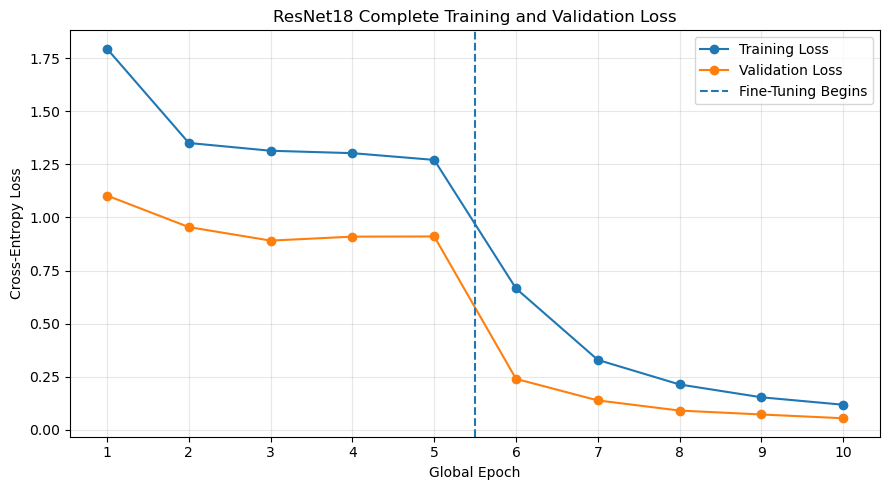

In [80]:
stage1_length = len(stage1_history["epoch"])
global_epochs = combined_history["global_epoch"]

plt.figure(figsize=(9, 5))

plt.plot(
    global_epochs,
    combined_history["train_loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    global_epochs,
    combined_history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.axvline(
    x=stage1_length + 0.5,
    linestyle="--",
    label="Fine-Tuning Begins"
)

plt.title("ResNet18 Complete Training and Validation Loss")
plt.xlabel("Global Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.xticks(global_epochs)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

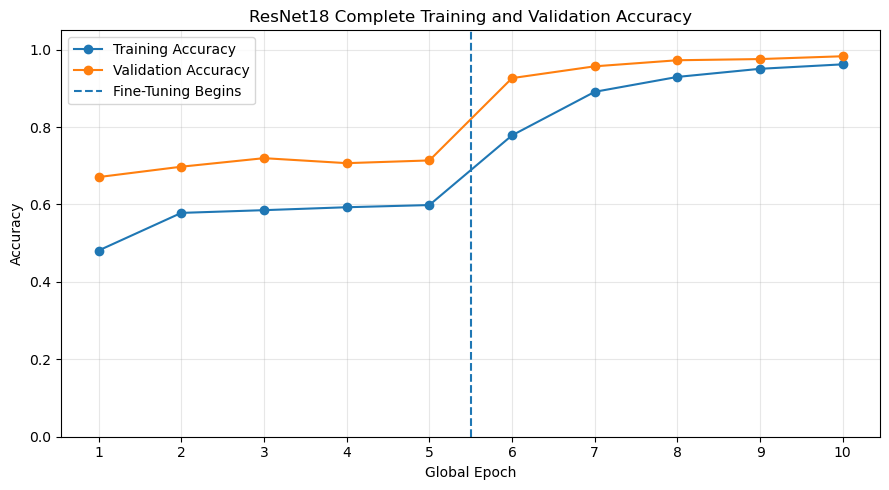

In [81]:
plt.figure(figsize=(9, 5))

plt.plot(
    global_epochs,
    combined_history["train_accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    global_epochs,
    combined_history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.axvline(
    x=stage1_length + 0.5,
    linestyle="--",
    label="Fine-Tuning Begins"
)

plt.title("ResNet18 Complete Training and Validation Accuracy")
plt.xlabel("Global Epoch")
plt.ylabel("Accuracy")
plt.xticks(global_epochs)
plt.ylim(0, 1.05)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [82]:
history_dataframe.to_csv(HISTORY_PATH, index=False)

print("Training history saved to:", HISTORY_PATH)

Training history saved to: ../results/resnet18_training_history.csv


##### 17. Load the Best Fine-Tuned Model

The checkpoint with the lowest validation loss during fine-tuning is loaded before final test evaluation.

The test set has not been used for training, learning-rate adjustment, early stopping or model selection.

In [83]:
checkpoint = torch.load(FINAL_MODEL_PATH, map_location=device)

model.load_state_dict(checkpoint["model_state_dict"])

model = model.to(device)
model.eval()

print("Best fine-tuned model loaded.")
print("Best epoch:", checkpoint["best_epoch"])

print("Best validation loss:", f"{checkpoint['best_val_loss']:.4f}")

print("Validation accuracy at best-loss epoch:", f"{checkpoint['best_val_accuracy']:.4f}")

Best fine-tuned model loaded.
Best epoch: 5
Best validation loss: 0.0551
Validation accuracy at best-loss epoch: 0.9830


##### 18. Test Set Evaluation

The final model is evaluated once on the independent test set.

The following metrics are calculated:

- test loss;
- accuracy;
- macro precision;
- macro recall;
- macro F1-score;
- weighted precision;
- weighted recall;
- weighted F1-score.

Macro metrics assign equal importance to every class, while weighted metrics account for class frequency.

In [84]:
def evaluate_model(model, data_loader, criterion, device):
    model.eval()
    
    running_loss = 0.0
    
    all_labels = []
    all_predictions = []
    all_probabilities = []
    
    inference_start_time = time.time()
    
    with torch.no_grad():
        for batch_index, (inputs, labels) in enumerate(
            data_loader,
            start=1
        ):
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            probabilities = torch.softmax(
                outputs,
                dim=1
            )
            
            predictions = torch.argmax(
                probabilities,
                dim=1
            )
            
            running_loss += (
                loss.item() * inputs.size(0)
            )
            
            all_labels.extend(
                labels.cpu().numpy()
            )
            
            all_predictions.extend(
                predictions.cpu().numpy()
            )
            
            all_probabilities.extend(
                probabilities.cpu().numpy()
            )
            
            if (
                batch_index == 1
                or batch_index % 100 == 0
                or batch_index == len(data_loader)
            ):
                print(
                    f"Evaluation batch "
                    f"{batch_index}/"
                    f"{len(data_loader)}"
                )
    
    inference_seconds = (
        time.time() - inference_start_time
    )
    
    average_loss = (
        running_loss / len(data_loader.dataset)
    )
    
    return {
        "loss": average_loss,
        "labels": np.array(all_labels),
        "predictions": np.array(all_predictions),
        "probabilities": np.array(
            all_probabilities
        ),
        "inference_seconds": inference_seconds
    }


test_results = evaluate_model(
    model=model,
    data_loader=test_loader,
    criterion=criterion,
    device=device
)

Evaluation batch 1/790
Evaluation batch 100/790
Evaluation batch 200/790
Evaluation batch 300/790
Evaluation batch 400/790
Evaluation batch 500/790
Evaluation batch 600/790
Evaluation batch 700/790
Evaluation batch 790/790


In [85]:
y_true = test_results["labels"]
y_pred = test_results["predictions"]
y_probability = test_results["probabilities"]

test_accuracy = accuracy_score(y_true, y_pred)

(
    macro_precision,
    macro_recall,
    macro_f1,
    _
) = precision_recall_fscore_support(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

(
    weighted_precision,
    weighted_recall,
    weighted_f1,
    _
) = precision_recall_fscore_support(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

test_metrics = {
    "model_name": "ResNet18",
    "test_loss": float(test_results["loss"]),
    "test_accuracy": float(test_accuracy),
    "macro_precision": float(macro_precision),
    "macro_recall": float(macro_recall),
    "macro_f1": float(macro_f1),
    "weighted_precision": float(
        weighted_precision
    ),
    "weighted_recall": float(
        weighted_recall
    ),
    "weighted_f1": float(weighted_f1),
    "inference_seconds": float(
        test_results["inference_seconds"]
    ),
    "milliseconds_per_image": float(
        1000
        * test_results["inference_seconds"]
        / len(test_dataset)
    )
}

metrics_dataframe = pd.DataFrame(
    [test_metrics]
).set_index("model_name")

display(metrics_dataframe.round(4))

,test_loss,test_accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,inference_seconds,milliseconds_per_image
model_name,,,,,,,,,,
ResNet18,0.2091,0.9348,0.9086,0.9132,0.9063,0.9398,0.9348,0.935,448.7868,35.5334


In [86]:
print("ResNet18 Test Results")
print("-" * 45)

print(
    f"Test loss:          "
    f"{test_metrics['test_loss']:.4f}"
)

print(
    f"Test accuracy:      "
    f"{100 * test_metrics['test_accuracy']:.2f}%"
)

print(
    f"Macro precision:    "
    f"{test_metrics['macro_precision']:.4f}"
)

print(
    f"Macro recall:       "
    f"{test_metrics['macro_recall']:.4f}"
)

print(
    f"Macro F1-score:     "
    f"{test_metrics['macro_f1']:.4f}"
)

print(
    f"Weighted F1-score:  "
    f"{test_metrics['weighted_f1']:.4f}"
)

print(
    f"Inference time:     "
    f"{test_metrics['inference_seconds']:.2f} seconds"
)

print(
    f"Time per image:     "
    f"{test_metrics['milliseconds_per_image']:.3f} ms"
)

ResNet18 Test Results
---------------------------------------------
Test loss:          0.2091
Test accuracy:      93.48%
Macro precision:    0.9086
Macro recall:       0.9132
Macro F1-score:     0.9063
Weighted F1-score:  0.9350
Inference time:     448.79 seconds
Time per image:     35.533 ms


##### 19. Classification Report

A classification report is generated to show precision, recall, F1-score and support for each traffic sign class.

In [87]:
report_dictionary = classification_report(
    y_true,
    y_pred,
    labels=range(num_classes),
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

classification_report_dataframe = (
    pd.DataFrame(report_dictionary)
    .transpose()
)

display(classification_report_dataframe.round(4))

,precision,recall,f1-score,support
Class 0,0.7761,0.8667,0.8189,60.0000
Class 1,0.9649,0.8403,0.8983,720.0000
Class 2,0.7964,0.9440,0.8639,750.0000
Class 3,0.9722,0.8533,0.9089,450.0000
Class 4,0.9611,0.9742,0.9676,660.0000
Class 5,0.8819,0.9127,0.8970,630.0000
Class 6,0.9850,0.8733,0.9258,150.0000
Class 7,0.9537,0.9622,0.9580,450.0000
Class 8,0.9527,0.8956,0.9233,450.0000
Class 9,0.9854,0.9875,0.9865,480.0000


##### 20. Raw Confusion Matrix

The raw confusion matrix shows the absolute number of correct and incorrect predictions for each class.

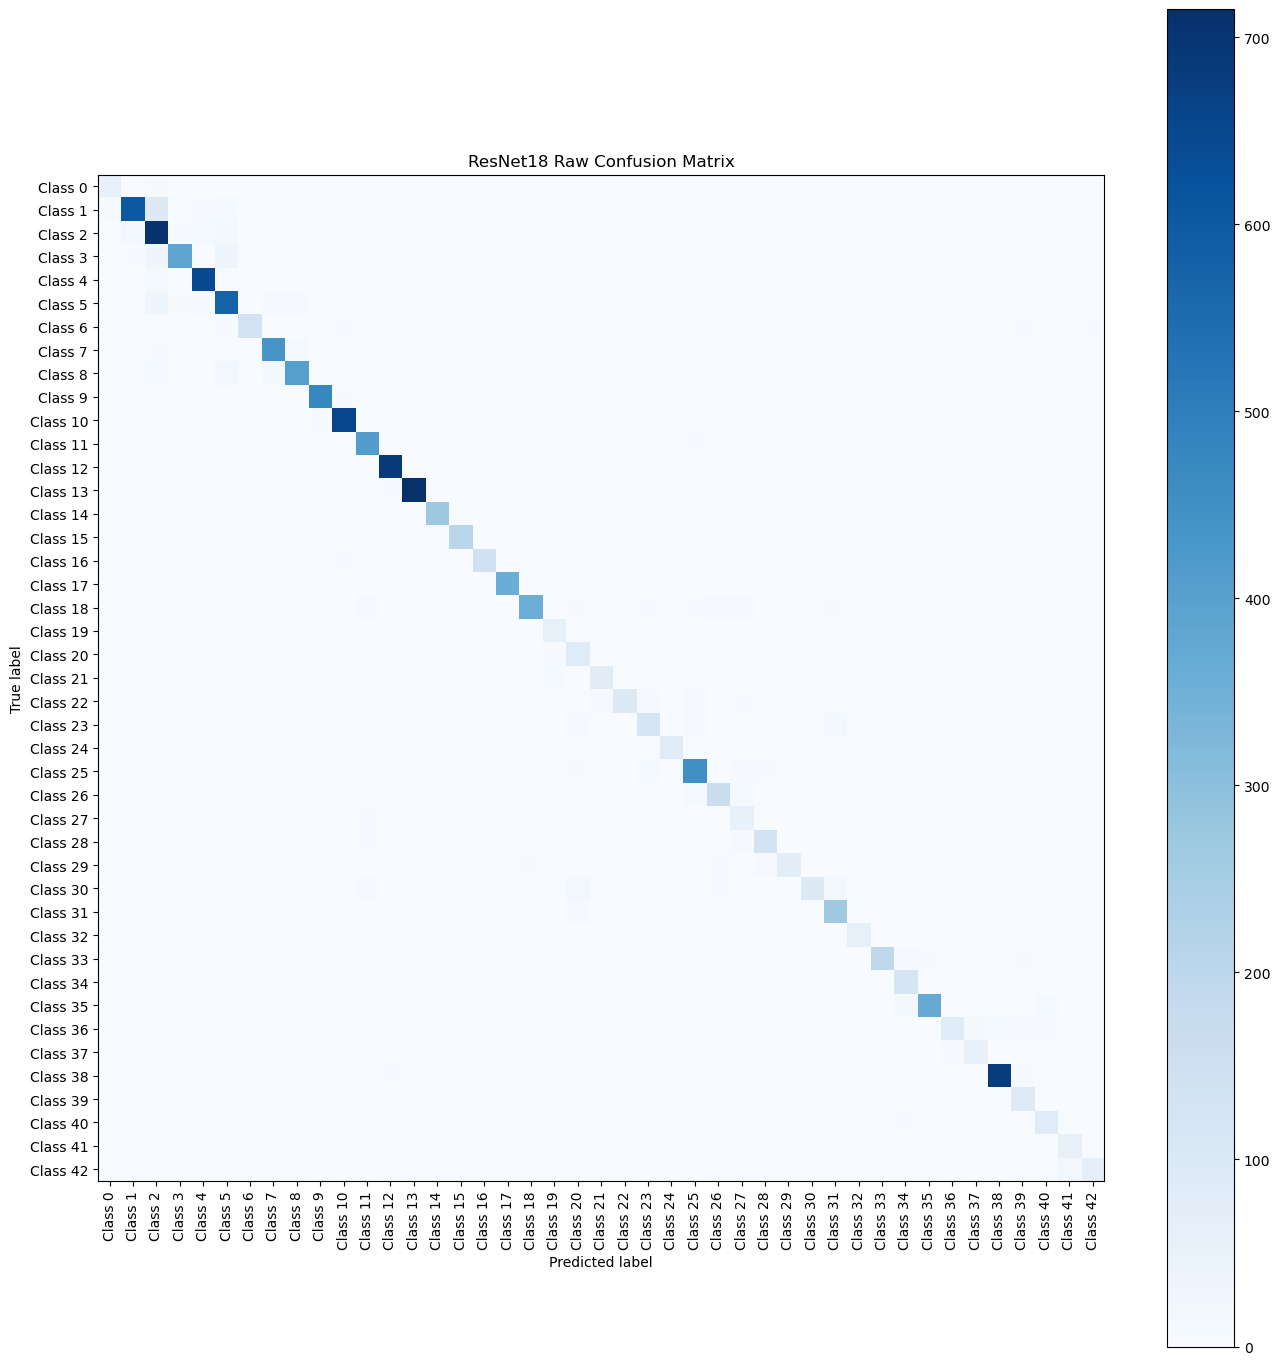

In [88]:
raw_confusion_matrix = confusion_matrix(
    y_true,
    y_pred,
    labels=range(num_classes)
)

figure_size = max(12, num_classes * 0.32)

fig, axis = plt.subplots(figsize=(figure_size, figure_size))

confusion_display = ConfusionMatrixDisplay(
    confusion_matrix=raw_confusion_matrix,
    display_labels=class_names
)

confusion_display.plot(
    ax=axis,
    cmap="Blues",
    xticks_rotation=90,
    include_values=False,
    colorbar=True
)

axis.set_title("ResNet18 Raw Confusion Matrix")

plt.tight_layout()
plt.show()

##### 21. Normalised Confusion Matrix

The confusion matrix is normalised by true class.

Each row represents the prediction distribution for one actual class. The diagonal values therefore correspond to class recall.

The normalised version is more suitable for comparing classes with different sample sizes.

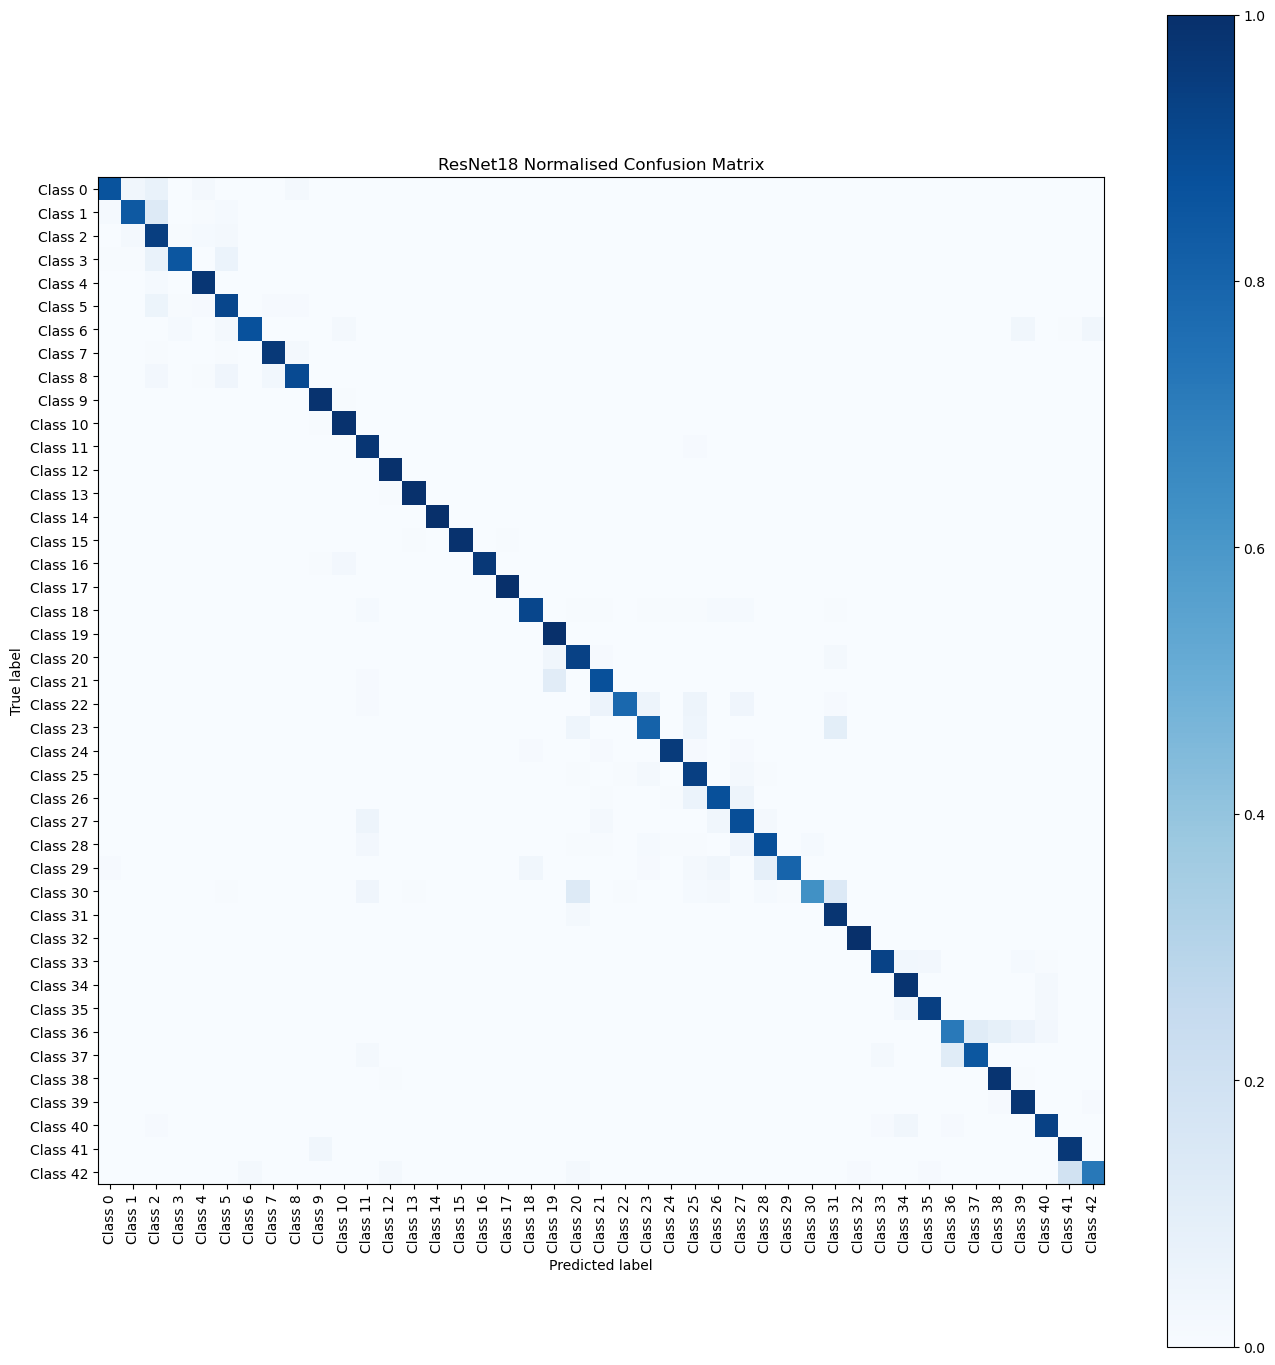

In [89]:
normalised_confusion_matrix = confusion_matrix(
    y_true,
    y_pred,
    labels=range(num_classes),
    normalize="true"
)

fig, axis = plt.subplots(figsize=(figure_size, figure_size))

confusion_display = ConfusionMatrixDisplay(
    confusion_matrix=normalised_confusion_matrix,
    display_labels=class_names
)

confusion_display.plot(
    ax=axis,
    cmap="Blues",
    xticks_rotation=90,
    include_values=False,
    colorbar=True
)

axis.set_title("ResNet18 Normalised Confusion Matrix")

plt.tight_layout()
plt.show()

##### 22. Per-Class Performance

Per-class precision, recall and F1-score are calculated.

For single-label multi-class classification, per-class accuracy calculated from each true-class row is equivalent to class recall.

In [90]:
class_support = raw_confusion_matrix.sum(axis=1)
class_correct = np.diag(raw_confusion_matrix)

per_class_accuracy = np.divide(
    class_correct,
    class_support,
    out=np.zeros_like(
        class_correct,
        dtype=float
    ),
    where=class_support != 0
)

(
    per_class_precision,
    per_class_recall,
    per_class_f1,
    _
) = precision_recall_fscore_support(
    y_true,
    y_pred,
    labels=range(num_classes),
    average=None,
    zero_division=0
)

per_class_results = pd.DataFrame({
    "class_index": range(num_classes),
    "original_class_id": [
        index_to_label[index]
        for index in range(num_classes)
    ],
    "class_name": class_names,
    "support": class_support,
    "correct_predictions": class_correct,
    "accuracy": per_class_accuracy,
    "precision": per_class_precision,
    "recall": per_class_recall,
    "f1_score": per_class_f1
})

display(
    per_class_results
    .sort_values(
        "f1_score",
        ascending=False
    )
    .round(4)
)

,class_index,original_class_id,class_name,support,correct_predictions,accuracy,precision,recall,f1_score
14,14,14,Class 14,270,269,0.9963,1.0000,0.9963,0.9981
17,17,17,Class 17,360,359,0.9972,0.9972,0.9972,0.9972
13,13,13,Class 13,720,715,0.9931,0.9917,0.9931,0.9924
15,15,15,Class 15,210,208,0.9905,0.9905,0.9905,0.9905
12,12,12,Class 12,690,685,0.9928,0.9842,0.9928,0.9885
9,9,9,Class 9,480,474,0.9875,0.9854,0.9875,0.9865
10,10,10,Class 10,660,653,0.9894,0.9834,0.9894,0.9864
38,38,38,Class 38,690,679,0.9841,0.9841,0.9841,0.9841
32,32,32,Class 32,60,60,1.0000,0.9677,1.0000,0.9836
16,16,16,Class 16,150,145,0.9667,0.9932,0.9667,0.9797


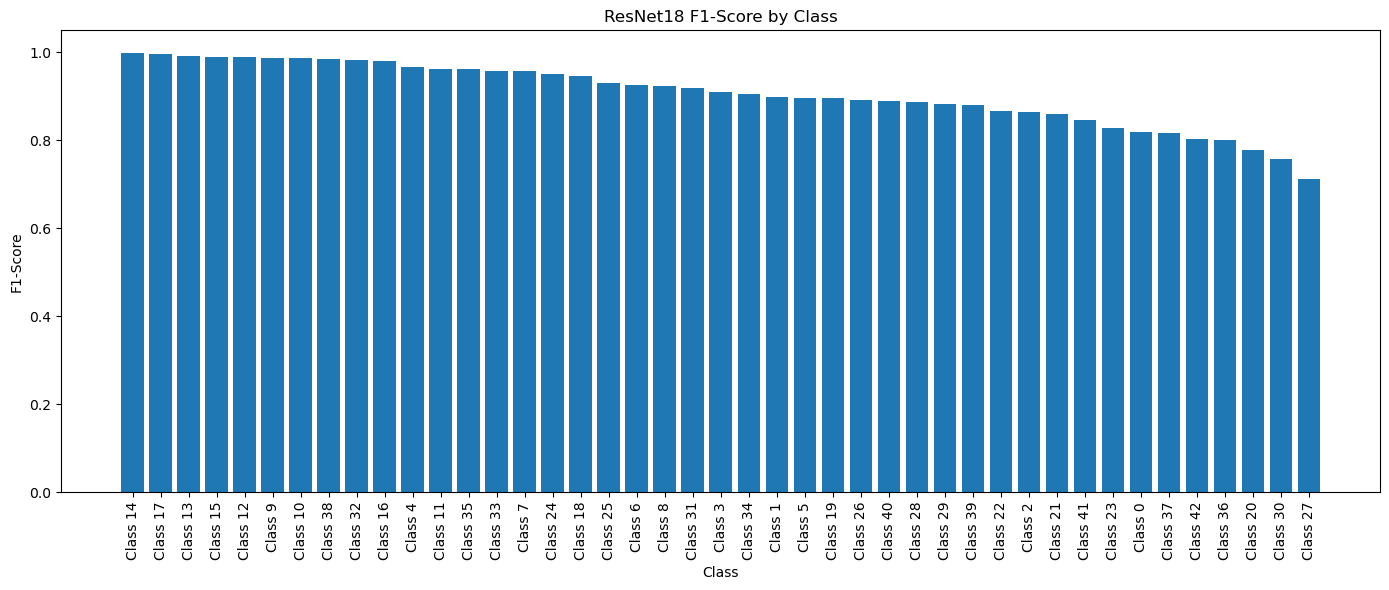

In [91]:
sorted_class_results = (
    per_class_results
    .sort_values(
        "f1_score",
        ascending=False
    )
)

plt.figure(figsize=(14, 6))

plt.bar(
    sorted_class_results["class_name"],
    sorted_class_results["f1_score"]
)

plt.title("ResNet18 F1-Score by Class")
plt.xlabel("Class")
plt.ylabel("F1-Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

##### 23. Best and Worst Performing Classes

The five classes with the highest and lowest F1-scores are identified.

F1-score is used because it considers both precision and recall.

In [92]:
number_to_show = min(5, num_classes)

best_classes = per_class_results.nlargest(
    number_to_show,
    "f1_score"
)

worst_classes = per_class_results.nsmallest(
    number_to_show,
    "f1_score"
)

print("Best-performing classes:")
display(best_classes.round(4))

print("Worst-performing classes:")
display(worst_classes.round(4))

Best-performing classes:


,class_index,original_class_id,class_name,support,correct_predictions,accuracy,precision,recall,f1_score
14,14,14,Class 14,270,269,0.9963,1.0000,0.9963,0.9981
17,17,17,Class 17,360,359,0.9972,0.9972,0.9972,0.9972
13,13,13,Class 13,720,715,0.9931,0.9917,0.9931,0.9924
15,15,15,Class 15,210,208,0.9905,0.9905,0.9905,0.9905
12,12,12,Class 12,690,685,0.9928,0.9842,0.9928,0.9885


Worst-performing classes:


,class_index,original_class_id,class_name,support,correct_predictions,accuracy,precision,recall,f1_score
27,27,27,Class 27,60,53,0.8833,0.5955,0.8833,0.7114
30,30,30,Class 30,150,94,0.6267,0.9592,0.6267,0.7581
20,20,20,Class 20,90,84,0.9333,0.6667,0.9333,0.7778
36,36,36,Class 36,120,86,0.7167,0.9053,0.7167,0.8000
42,42,42,Class 42,90,65,0.7222,0.9028,0.7222,0.8025


##### Discussion

The strongest-performing classes were **Classes 14, 17, 13, 15 and 12**, with F1-scores ranging from **0.9885 to 0.9981**. These classes may contain visually distinctive shapes, colours or internal symbols.

The weakest-performing classes were **Classes 27, 30, 20, 36 and 42**, with F1-scores ranging from **0.7114 to 0.8025**. However, the error patterns differed between these classes. Class 27 achieved relatively high recall but low precision, indicating that other classes were frequently predicted incorrectly as Class 27. In contrast, Class 30 achieved high precision but low recall, meaning that many genuine Class 30 images were assigned to other classes. 

The largest individual confusion occurred when **Class 1 was predicted as Class 2**, affecting 90 test images and 12.50% of the true Class 1 samples. Other notable errors included Class 30 being predicted as Classes 31 and 20, and Class 42 being predicted as Class 41. These errors suggest that visually similar sign shapes, colours or internal symbols remain difficult for the model to distinguish.

##### 24. Most Common Misclassifications

The most frequent off-diagonal confusion pairs are identified to support detailed error analysis.

In [93]:
confusion_pairs = []

for true_index in range(num_classes):
    for predicted_index in range(num_classes):
        
        if true_index == predicted_index:
            continue
        
        confusion_pairs.append({
            "true_class": (
                class_names[true_index]
            ),
            "predicted_class": (
                class_names[predicted_index]
            ),
            "count": int(
                raw_confusion_matrix[
                    true_index,
                    predicted_index
                ]
            ),
            "true_class_rate": float(
                normalised_confusion_matrix[
                    true_index,
                    predicted_index
                ]
            )
        })

confusion_pairs_dataframe = pd.DataFrame(confusion_pairs)

most_common_confusions = (
    confusion_pairs_dataframe
    .query("count > 0")
    .sort_values(
        ["count", "true_class_rate"],
        ascending=False
    )
    .head(10)
)

display(most_common_confusions.round(4))

,true_class,predicted_class,count,true_class_rate
43,Class 1,Class 2,90,0.1250
212,Class 5,Class 2,32,0.0508
128,Class 3,Class 2,31,0.0689
130,Class 3,Class 5,28,0.0622
1290,Class 30,Class 31,20,0.1333
1280,Class 30,Class 20,19,0.1267
341,Class 8,Class 5,19,0.0422
1805,Class 42,Class 41,17,0.1889
85,Class 2,Class 1,16,0.0213
996,Class 23,Class 31,15,0.1000


##### 25. Prediction Examples

Correct and incorrect test predictions are displayed for qualitative analysis.

The confidence value is the maximum softmax probability produced by the model.

In [94]:
def collect_prediction_examples(
    model,
    dataset,
    device,
    maximum_examples=8,
    correct=True
):
    examples = []
    model.eval()
    
    with torch.no_grad():
        for dataset_index in range(len(dataset)):
            
            image, true_label = dataset[
                dataset_index
            ]
            
            output = model(
                image.unsqueeze(0).to(device)
            )
            
            probabilities = torch.softmax(
                output,
                dim=1
            )
            
            confidence, predicted_label = (
                torch.max(
                    probabilities,
                    dim=1
                )
            )
            
            predicted_label = (
                predicted_label.item()
            )
            
            confidence = confidence.item()
            
            prediction_is_correct = (
                predicted_label == true_label
            )
            
            if prediction_is_correct == correct:
                examples.append({
                    "image": image,
                    "true_label": true_label,
                    "predicted_label": (
                        predicted_label
                    ),
                    "confidence": confidence
                })
            
            if len(examples) >= maximum_examples:
                break
    
    return examples

In [95]:
def display_prediction_examples(examples, title): 
    if not examples:
        print("No examples were found.")
        return
    
    columns = 4
    rows = int(np.ceil(len(examples) / columns))
    
    plt.figure(figsize=(16, 4 * rows))
    
    for index, example in enumerate(examples):
        plt.subplot(rows, columns, index + 1)
        
        image = denormalise_image(example["image"])
        
        image = (image.permute(1, 2, 0).numpy())
        
        plt.imshow(image)
        
        true_name = class_names[example["true_label"]]
        
        predicted_name = class_names[example["predicted_label"]]
        
        plt.title(
            f"True: {true_name}\n"
            f"Predicted: {predicted_name}\n"
            f"Confidence: "
            f"{example['confidence']:.2%}"
        )
        
        plt.axis("off")
    
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

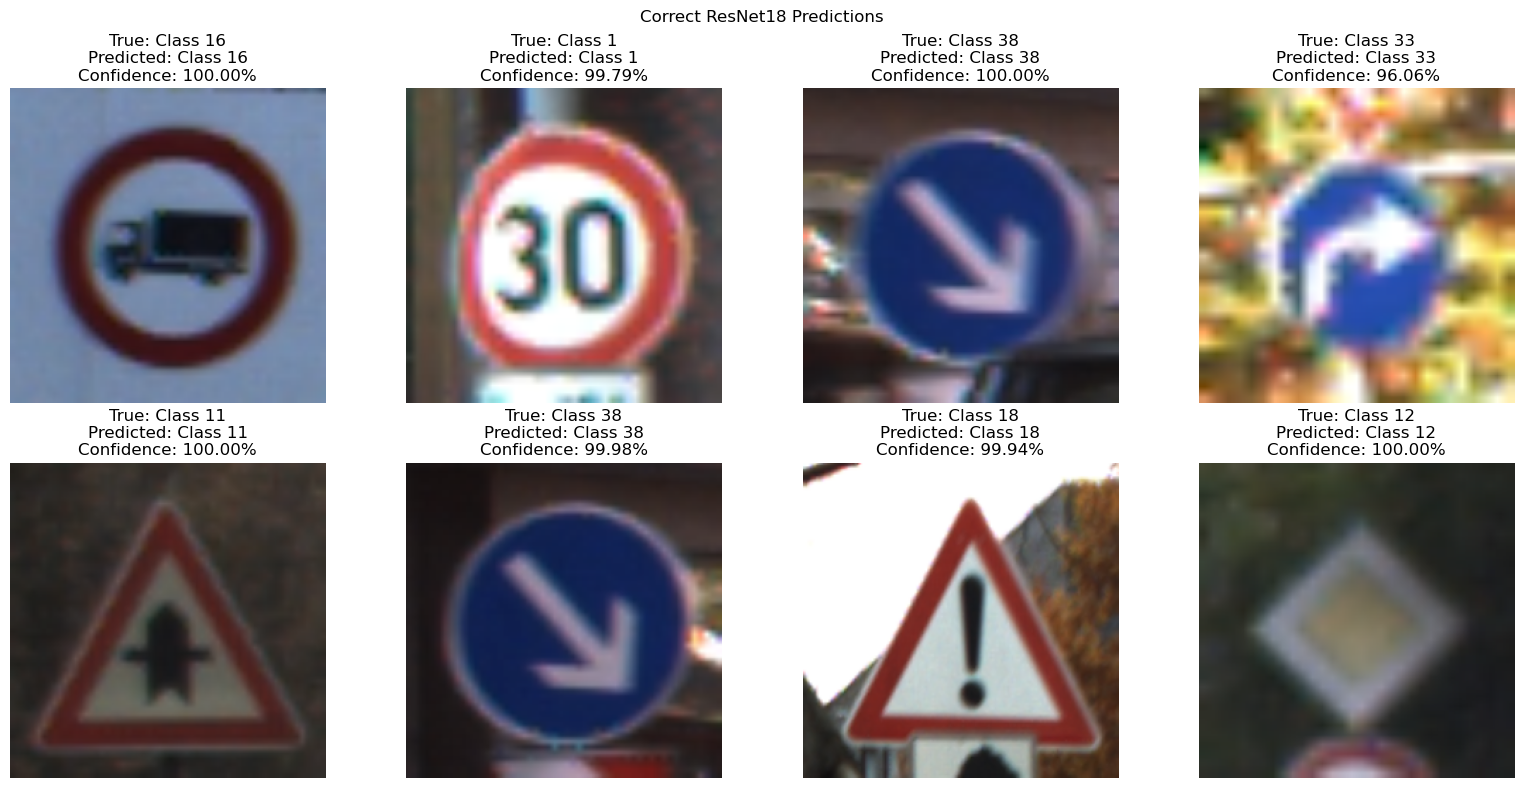

In [96]:
correct_examples = collect_prediction_examples(
    model=model,
    dataset=test_dataset,
    device=device,
    maximum_examples=8,
    correct=True
)

display_prediction_examples(correct_examples, "Correct ResNet18 Predictions")

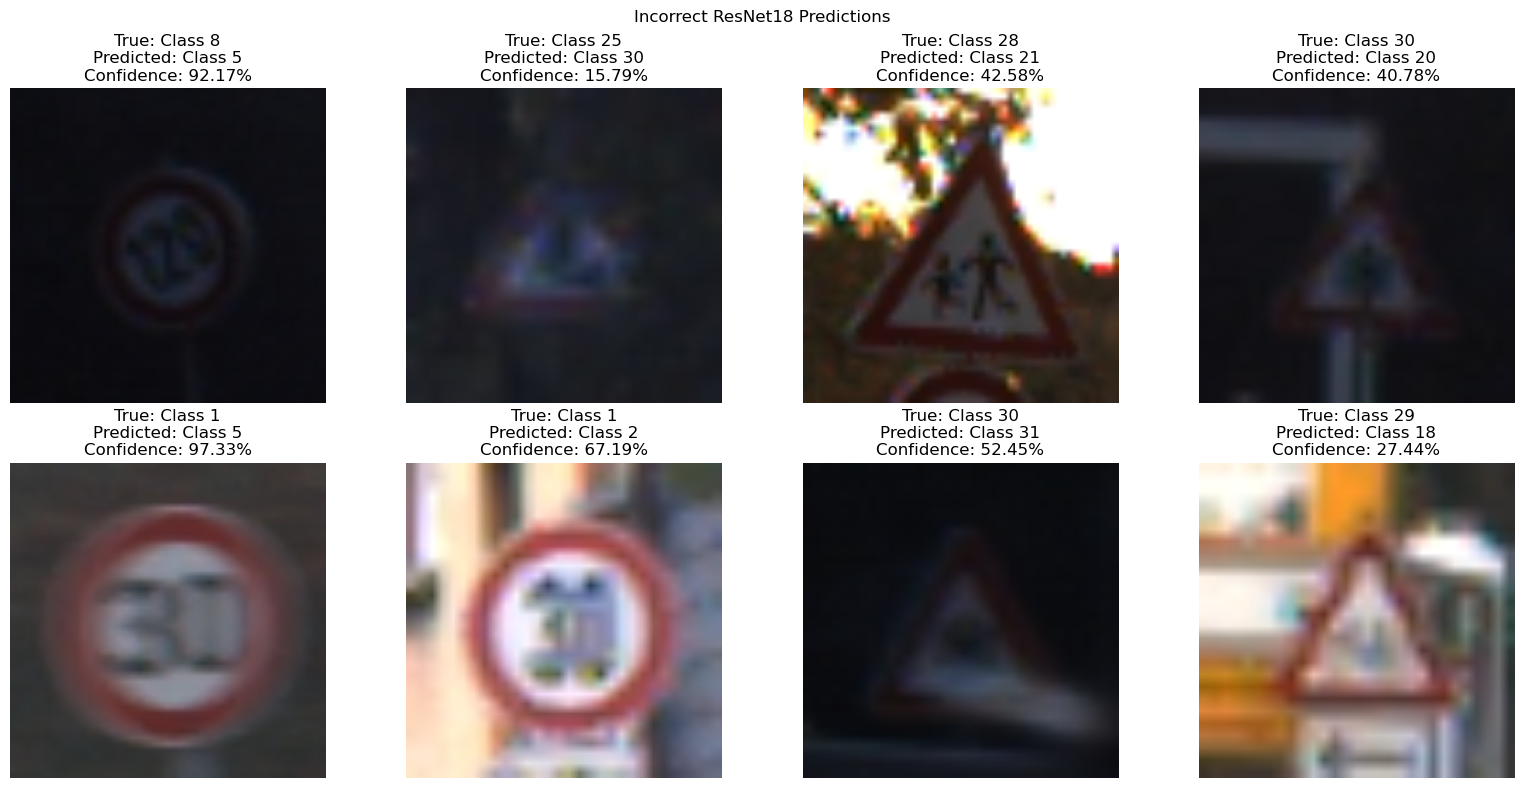

In [97]:
incorrect_examples = collect_prediction_examples(
    model=model,
    dataset=test_dataset,
    device=device,
    maximum_examples=8,
    correct=False
)

display_prediction_examples(incorrect_examples, "Incorrect ResNet18 Predictions")

##### 26. Model Efficiency

The parameter count, saved-model size, training time and inference time are recorded for comparison with the custom CNN and MobileNetV3 models.

The inference time is measured on the local CPU and should therefore be interpreted as a relative comparison under the same hardware conditions.

In [98]:
total_parameters, stage2_trainable_parameters = (count_parameters(model))

model_file_size_mb = (FINAL_MODEL_PATH.stat().st_size / (1024 ** 2))

total_training_seconds = (
    stage1_summary["training_seconds"]
    + stage2_summary["training_seconds"]
)

efficiency_results = {
    "total_parameters": int(
        total_parameters
    ),
    "stage2_trainable_parameters": int(
        stage2_trainable_parameters
    ),
    "model_file_size_mb": float(
        model_file_size_mb
    ),
    "total_training_seconds": float(
        total_training_seconds
    ),
    "total_training_minutes": float(
        total_training_seconds / 60
    ),
    "test_inference_seconds": float(
        test_results["inference_seconds"]
    ),
    "milliseconds_per_test_image": float(
        test_metrics[
            "milliseconds_per_image"
        ]
    )
}

efficiency_dataframe = pd.DataFrame([efficiency_results], index=["ResNet18"])

display(efficiency_dataframe.round(4))

,total_parameters,stage2_trainable_parameters,model_file_size_mb,total_training_seconds,total_training_minutes,test_inference_seconds,milliseconds_per_test_image
ResNet18,11198571,8415787,42.7948,26328.0854,438.8014,448.7868,35.5334


##### 27. Save Experimental Results

The overall metrics, training history, per-class results and confusion matrices are saved for use in the final model comparison notebook.

In [99]:
all_saved_metrics = {
    **test_metrics,
    **efficiency_results,
    
    "stage1_best_epoch": int(
        stage1_summary["best_epoch"]
    ),
    
    "stage1_best_val_loss": float(
        stage1_summary["best_val_loss"]
    ),
    
    "stage1_best_val_accuracy": float(
        stage1_summary[
            "best_val_accuracy"
        ]
    ),
    
    "stage2_best_epoch": int(
        stage2_summary["best_epoch"]
    ),
    
    "stage2_best_val_loss": float(
        stage2_summary["best_val_loss"]
    ),
    
    "stage2_best_val_accuracy": float(
        stage2_summary[
            "best_val_accuracy"
        ]
    ),
    
    "batch_size": BATCH_SIZE,
    "image_size": IMAGE_SIZE,
    
    "stage1_learning_rate": (
        STAGE1_LR
    ),
    
    "stage2_backbone_learning_rate": (
        STAGE2_BACKBONE_LR
    ),
    
    "stage2_classifier_learning_rate": (
        STAGE2_CLASSIFIER_LR
    ),
    
    "random_seed": SEED,
    "device": str(device),
    "cpu_threads": torch.get_num_threads()
}

with open(
    METRICS_PATH,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        all_saved_metrics,
        file,
        indent=4
    )

per_class_results.to_csv(
    PER_CLASS_PATH,
    index=False
)

classification_report_dataframe.to_csv(
    RESULTS_DIR
    / "resnet18_classification_report.csv"
)

most_common_confusions.to_csv(
    RESULTS_DIR
    / "resnet18_common_confusions.csv",
    index=False
)

np.save(
    RESULTS_DIR
    / "resnet18_raw_confusion_matrix.npy",
    raw_confusion_matrix
)

np.save(
    RESULTS_DIR
    / "resnet18_normalised_confusion_matrix.npy",
    normalised_confusion_matrix
)

print("Results saved successfully:")
print("-", FINAL_MODEL_PATH)
print("-", METRICS_PATH)
print("-", HISTORY_PATH)
print("-", PER_CLASS_PATH)

Results saved successfully:
- ../models/resnet18_best.pth
- ../results/resnet18_metrics.json
- ../results/resnet18_training_history.csv
- ../results/resnet18_per_class_results.csv


##### 28. Summary

This notebook implemented a pretrained ResNet18 model for traffic sign classification using a two-stage transfer learning strategy.

During the first stage, the pretrained convolutional backbone was frozen and only the newly added classification head was trained. During the second stage, the final residual block was unfrozen and fine-tuned using a smaller learning rate.

The final model achieved:

- **Test accuracy:** 93.48%
- **Macro precision:** 0.9086
- **Macro recall:** 0.9132
- **Macro F1-score:** 0.9063
- **Weighted F1-score:** 0.9350

The results demonstrate that fine-tuning the higher-level ResNet18 features produced a substantial improvement over using the pretrained network only as a fixed feature extractor. The difference between the validation accuracy of 98.30% and test accuracy of 93.48% indicates a moderate generalisation gap, potentially caused by differences in difficulty, image quality or viewing conditions between the validation and independent test sets.

Per-class analysis indicated that **Classes 14, 17, 13, 15 and 12** were classified most reliably, whereas **Classes 27, 30, 20, 36 and 42** produced the lowest F1-scores.

The most frequent classification error occurred when **Class 1 was predicted as Class 2**. Additional systematic confusions included **Class 30 with Classes 31 and 20**, and **Class 42 with Class 41**. These errors are likely related to similarities in visual appearance and subtle differences between traffic sign categories.

The model contained approximately **11.20 million parameters**, occupied **42.79 MB** when saved, and required approximately **35.53 milliseconds per image** for inference on the local CPU. The saved results will later be compared with the HOG-SVM baseline, custom CNN and MobileNetV3 model.

##### 29. Experiment Configuration Summary

In [100]:
configuration_summary = pd.DataFrame({
    "Setting": [
        "Architecture",
        "Pretraining dataset",
        "Training device",
        "Input size",
        "Batch size",
        "Number of workers",
        "Stage 1 maximum epochs",
        "Stage 1 learning rate",
        "Fine-tuned components",
        "Stage 2 maximum epochs",
        "Stage 2 backbone learning rate",
        "Stage 2 classifier learning rate",
        "Early stopping patience",
        "Random seed"
    ],
    
    "Value": [
        "ResNet18",
        "ImageNet",
        "CPU",
        f"{IMAGE_SIZE} × {IMAGE_SIZE}",
        BATCH_SIZE,
        NUM_WORKERS,
        STAGE1_EPOCHS,
        STAGE1_LR,
        "layer4 and classification head",
        STAGE2_EPOCHS,
        STAGE2_BACKBONE_LR,
        STAGE2_CLASSIFIER_LR,
        PATIENCE,
        SEED
    ]
})

display(configuration_summary)

,Setting,Value
0,Architecture,ResNet18
1,Pretraining dataset,ImageNet
2,Training device,CPU
3,Input size,224 × 224
4,Batch size,16
5,Number of workers,0
6,Stage 1 maximum epochs,5
7,Stage 1 learning rate,0.001
8,Fine-tuned components,layer4 and classification head
9,Stage 2 maximum epochs,5
